Matplotlib permite crear experiencias interactivas tanto en terminales como en notebooks. Aprovecharemos el modo interactivo, selectores y widgets para responder a eventos del usuario sin abandonar la API orientada a objetos.

12.1 plt.ion() y gráficos interactivos

El modo interactivo actualiza la figura mientras el script sigue ejecutándose. Necesitás un backend interactivo: QtAgg (basado en Qt, ofrece ventanas modernas con soporte completo de widgets) o TkAgg (usa Tkinter, liviano y disponible por defecto en muchas instalaciones). Ambos permiten que la ventana de la figura procese eventos de zoom/pan sin bloquear tu código.

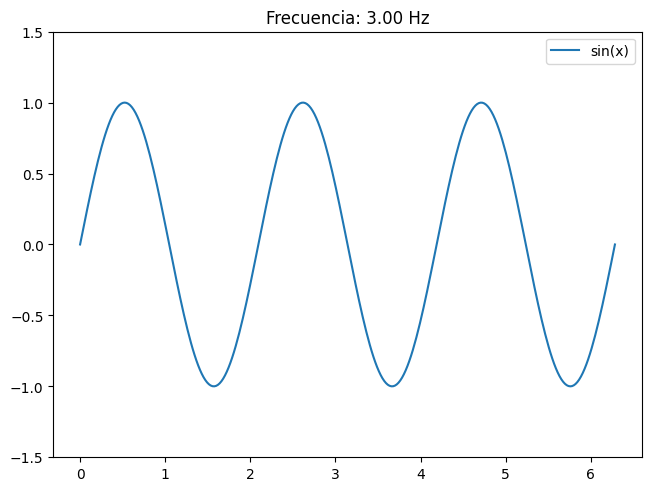

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

plt.ion()
fig, ax = plt.subplots(layout="constrained")
x = np.linspace(0, 2 * np.pi, 300)
(line,) = ax.plot(x, np.sin(x), label="sin(x)")
ax.set_ylim(-1.5, 1.5)
ax.legend()
fig.canvas.draw_idle()

for f in np.linspace(1, 3, 30):
    y = np.sin(f * x)
    line.set_ydata(y)
    ax.set_title(f"Frecuencia: {f:.2f} Hz")
    fig.canvas.draw_idle()
    fig.canvas.flush_events()
    time.sleep(0.05)

plt.ioff()
plt.show()

💡 Si no ves actualizaciones, verificá el backend con matplotlib.get_backend() o probá en un entorno notebook con %matplotlib widget.

12.2 Zoom, pan y selección
La barra de herramientas de cualquier figura incluye zoom y pan. Para selecciones más avanzadas Matplotlib dispone de SpanSelector, RectangleSelector, LassoSelector, etc.

Selección horizontal con SpanSelector

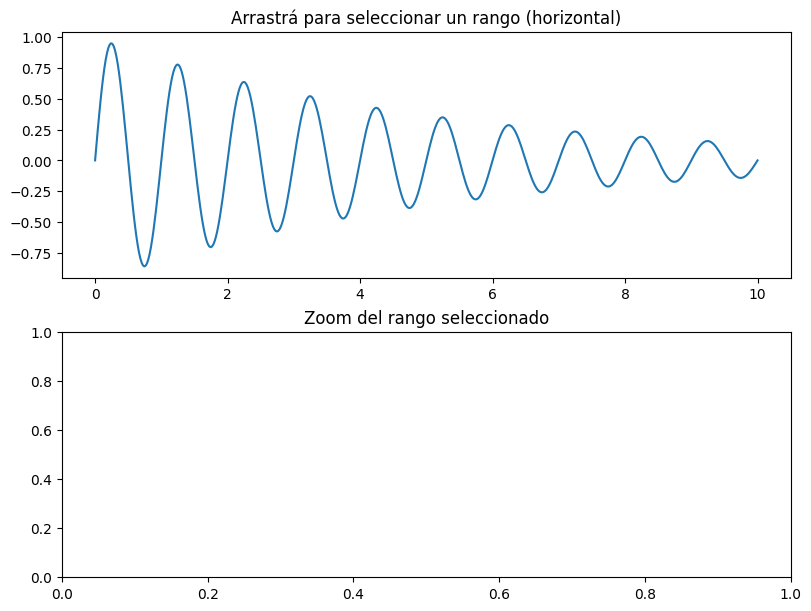

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import SpanSelector

x = np.linspace(0, 10, 500)
y = np.sin(2 * np.pi * x) * np.exp(-0.2 * x)

fig, (ax, ax_zoom) = plt.subplots(2, 1, figsize=(8, 6), layout="constrained")
ax.plot(x, y)
ax.set_title("Arrastrá para seleccionar un rango (horizontal)")
ax_zoom.set_title("Zoom del rango seleccionado")

def onselect(xmin, xmax):
    mask = (x >= xmin) & (x <= xmax)
    ax_zoom.clear()
    ax_zoom.plot(x[mask], y[mask])
    ax_zoom.set_title(f"Rango seleccionado: {xmin:.2f} a {xmax:.2f}")
    fig.canvas.draw_idle()

span = SpanSelector(
    ax,
    onselect,
    direction="horizontal",
    useblit=True,
    props=dict(alpha=0.3),
    interactive=True
)

plt.show()

Selección rectangular con RectangleSelector

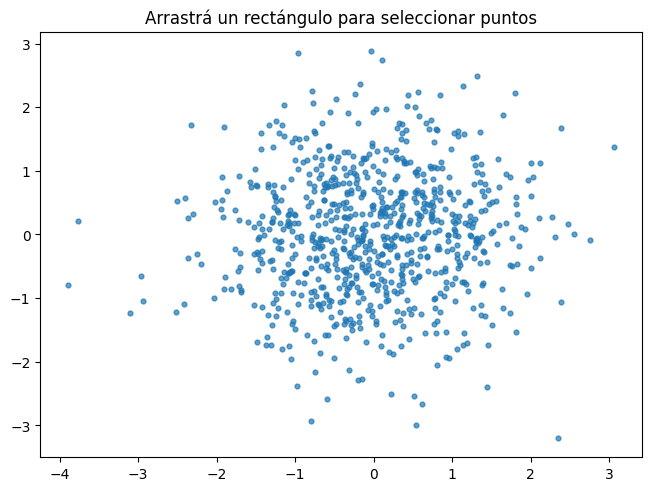

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector

rng = np.random.default_rng(0)
x = rng.normal(0, 1, 800)
y = rng.normal(0, 1, 800)

fig, ax = plt.subplots(layout="constrained")
pts = ax.scatter(x, y, s=12, alpha=0.7)
ax.set_title("Arrastrá un rectángulo para seleccionar puntos")

def onselect(eclick, erelease):
    xmin, xmax = sorted([eclick.xdata, erelease.xdata])
    ymin, ymax = sorted([eclick.ydata, erelease.ydata])
    sel = (x >= xmin) & (x <= xmax) & (y >= ymin) & (y <= ymax)
    pts.set_alpha(np.where(sel, 1.0, 0.3))
    fig.canvas.draw_idle()

rect = RectangleSelector(
    ax,
    onselect,
    useblit=True,
    button=[1],
    props=dict(facecolor="tab:blue", alpha=0.15, edgecolor="k")
)

plt.show()

12.3 Widgets básicos (Slider, RangeSlider, Button)
Los widgets permiten agregar controles sencillos dentro de la figura.

Slider para controlar parámetros

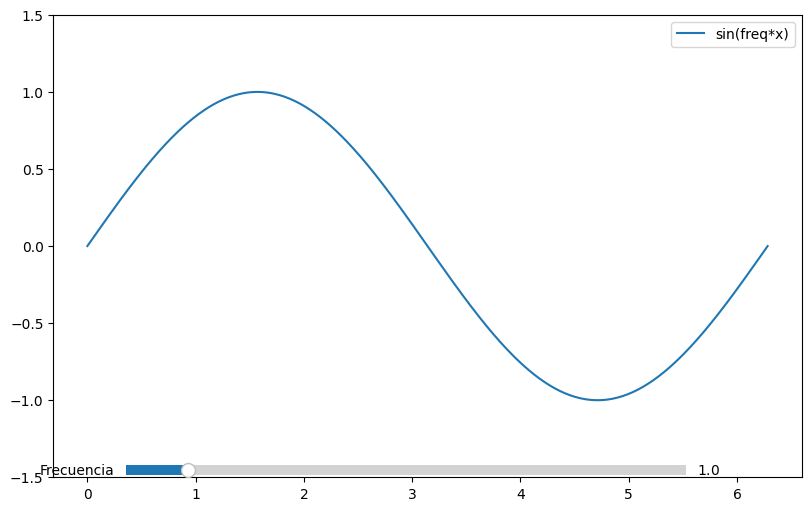

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

x = np.linspace(0, 2 * np.pi, 400)

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
(line,) = ax.plot(x, np.sin(1 * x), label="sin(freq*x)")
ax.set_ylim(-1.5, 1.5)
ax.legend()

ax_slider = fig.add_axes([0.15, 0.05, 0.7, 0.04])
slider_freq = Slider(ax=ax_slider, label="Frecuencia", valmin=0.5, valmax=5.0, valinit=1.0)

def actualizar(val):
    f = slider_freq.val
    line.set_ydata(np.sin(f * x))
    ax.set_title(f"f = {f:.2f}")
    fig.canvas.draw_idle()

slider_freq.on_changed(actualizar)
plt.show()

RangeSlider para definir intervalos

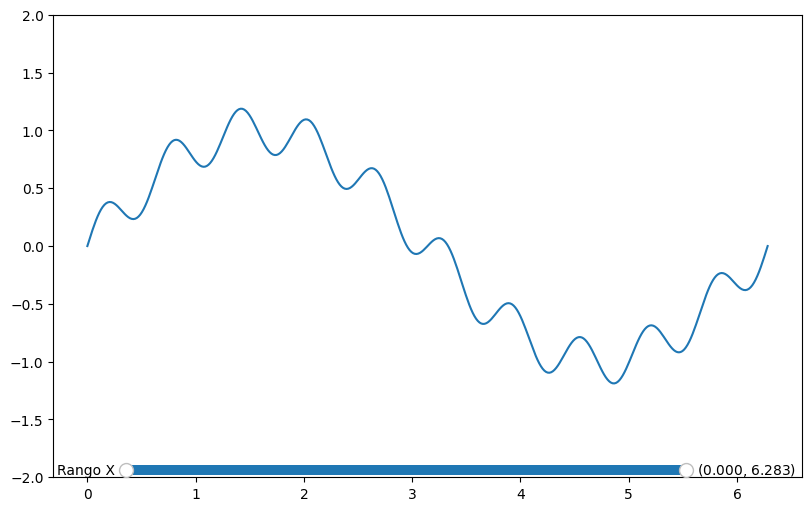

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RangeSlider

x = np.linspace(0, 2 * np.pi, 400)
y = np.sin(x) + 0.2 * np.sin(10 * x)

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
(line,) = ax.plot(x, y)
ax.set_ylim(-2, 2)

ax_r = fig.add_axes([0.15, 0.05, 0.7, 0.04])
rs = RangeSlider(
    ax=ax_r,
    label="Rango X",
    valmin=float(x.min()),
    valmax=float(x.max()),
    valinit=(float(x.min()), float(x.max()))
)

def actualizar_rango(val):
    xmin, xmax = rs.val
    ax.set_xlim(xmin, xmax)
    fig.canvas.draw_idle()

rs.on_changed(actualizar_rango)
plt.show()

Botón para resetear o lanzar acciones

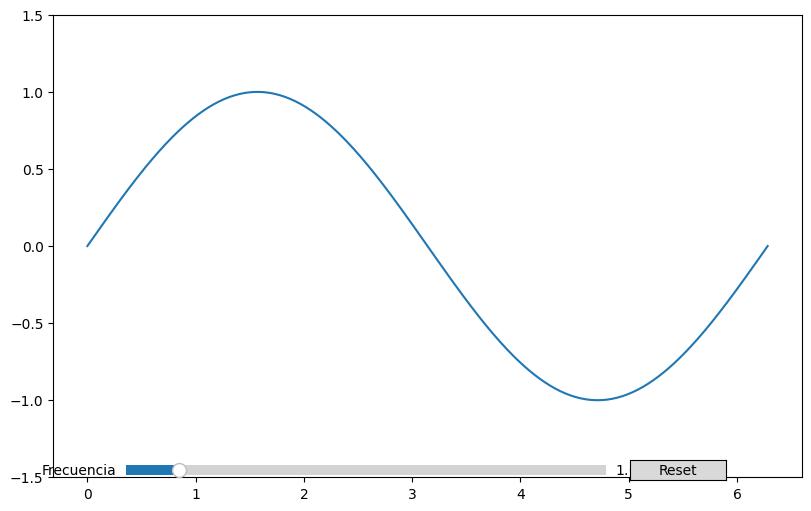

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

x = np.linspace(0, 2 * np.pi, 400)

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
(line,) = ax.plot(x, np.sin(1 * x))
ax.set_ylim(-1.5, 1.5)

ax_s = fig.add_axes([0.15, 0.05, 0.6, 0.04])
sl = Slider(ax=ax_s, label="Frecuencia", valmin=0.5, valmax=5.0, valinit=1.0)

def on_change(val):
    line.set_ydata(np.sin(sl.val * x))
    fig.canvas.draw_idle()

sl.on_changed(on_change)

ax_b = fig.add_axes([0.78, 0.05, 0.12, 0.04])
btn = Button(ax=ax_b, label="Reset")

def on_reset(event):
    sl.reset()

btn.on_clicked(on_reset)
plt.show()

Buenas prácticas de interactividad
Usá la API orientada a objetos (plt.subplots) y reservá espacio para controles (add_axes, GridSpec).

Mantené callbacks breves y reutilizables; evitá cálculos pesados dentro del evento.

Preferí draw_idle() a draw() para evitar repaints excesivos.

Para demos en notebooks usá FuncAnimation o %matplotlib widget; para dashboards considera ipywidgets, Panel o soluciones web.